In [1]:
import sys
import os

# SantanderCS 폴더를 프로젝트 루트로 설정
current_dir = os.getcwd()  # src 폴더
project_root = os.path.dirname(current_dir)  # SantanderCS 폴더


In [ ]:
# from common.preprocessing        import load_data, split_features_target, scale_data, undersample
# from common.feature_engineering  import add_statistical_features, drop_highly_correlated_features
# from common.modeling             import get_base_models, get_stacking_model
# from common.evaluation           import evaluate_model_cv, plot_shap_summary, plot_pca_2d

ModuleNotFoundError: No module named 'common'

In [4]:
import pandas as pd
import numpy  as np
from sklearn.preprocessing import StandardScaler

In [5]:
## 📘 01_preprocessing.ipynb
# 데이터 로딩
data_path_train = '../data/train.csv'
data_path_test  = '../data/test.csv'

# train, test = load_data(train_path=data_path_train, test_path=data_path_test)
train = pd.read_csv(data_path_train)
test = pd.read_csv(data_path_test)

In [6]:
# 피처와 타겟 분리
# X, y = split_features_target(train, test)
X = train.drop(['ID', 'TARGET'], axis=1)
y = train['TARGET']
X_test = test.drop(['ID'], axis=1)

# 스케일링
# X_train_scaled, X_test_scaled, scaler = scale_data(X_train=X, X_test=X_test)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


# 언더샘플링
neg = train[train.TARGET == 0].sample(n=20000, random_state=42)
pos = train[train.TARGET == 1]
train_balanced = pd.concat([neg, pos])
X_bal = train_balanced.drop(['ID', 'TARGET'], axis=1)
y_bal = train_balanced['TARGET']

In [7]:
## 📘 02_feature_engineering.ipynb
# SOF 통계 기반 파생 변수 생성 --------------------------------------- #
def add_features(df):
    df['sum']            = df.sum(axis=1)
    df['mean']           = df.mean(axis=1)
    df['std']            = df.std(axis=1)
    df['max']            = df.max(axis=1)
    df['min']            = df.min(axis=1)
    df['zero_count']     = (df == 0).sum(axis=1)
    df['negative_count'] = (df < 0).sum(axis=1)
    return df
# EOF add_features(df) -----------------------------------------------#

X_bal = add_features(X_bal)
X_test = add_features(X_test)

# 상관관계 기반 피처 제거
corr_matrix = X_bal.corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop     = [column for column in upper.columns if any(upper[column] > 0.95)]
X_bal.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

In [11]:
#to_drop
print(X_bal.shape, X_test.shape)

(23008, 259) (75818, 259)


In [12]:
## 📘 03_modeling_stack.ipynb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 모델 정의
xgb        = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
lgbm       = LGBMClassifier(random_state=42)
catboost   = CatBoostClassifier(verbose=0, random_state=42)
meta_model = LogisticRegression()

# 스태킹 앙상블
stacking_model = StackingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm), ('catboost', catboost)],
    final_estimator=meta_model,
    cv=5
)

# 학습 및 예측
stacking_model.fit(X_bal, y_bal)
test_preds = stacking_model.predict_proba(X_test)[:, 1]

# 제출 파일 생성
# submission = pd.DataFrame({'ID': test['ID'], 'TARGET': test_preds})
# submission.to_csv('submissions/submission_stack.csv', index=False)

c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:25:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 3008, number of negative: 20000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005562 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8460
[LightGBM] [Info] Number of data points in the train set: 23008, number of used features: 147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.130737 -> initscore=-1.894457
[LightGBM] [Info] Start training from score -1.894457


c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:26:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:26:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:26:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:26:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_

[LightGBM] [Info] Number of positive: 2406, number of negative: 16000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7736
[LightGBM] [Info] Number of data points in the train set: 18406, number of used features: 147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.130718 -> initscore=-1.894623
[LightGBM] [Info] Start training from score -1.894623
[LightGBM] [Info] Number of positive: 2406, number of negative: 16000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005760 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7723
[LightGBM] [Info] Number of data points in the train set: 18406, number of used features: 144
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.130718 -> initscore=-1.894623
[LightGBM] [Info] Start training from score -1.894623
[LightGBM] [

In [13]:
## 📘 04_shap_analysis.ipynb
import shap
import matplotlib.pyplot as plt

# SHAP 분석
explainer   = shap.Explainer(xgb, X_bal)
shap_values = explainer(X_bal)

# summary plot
shap.summary_plot(shap_values, X_bal, plot_type="bar")

# dependence plot 예시
shap.dependence_plot("sum", shap_values.values, X_bal)

c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:30:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:30:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:30:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:30:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_

PCA 적용 후 평균 AUC: 0.7403928668166566


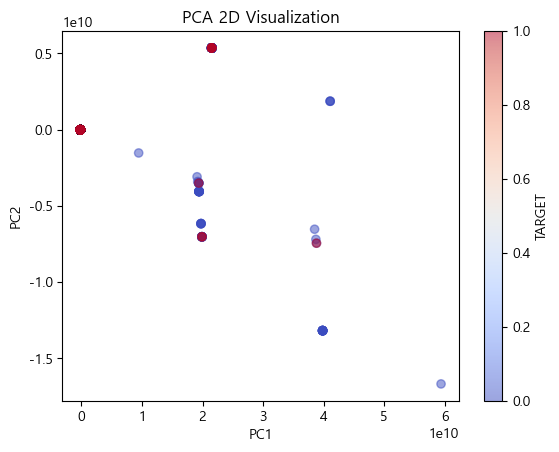

In [14]:
## 📘 05_pca_experiment.ipynb
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# PCA 적용
pca        = PCA(n_components=30)
X_pca      = pca.fit_transform(X_bal)
X_test_pca = pca.transform(X_test)

# 모델 학습 및 평가
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for train_idx, val_idx in skf.split(X_pca, y_bal):
    X_tr, X_val = X_pca[train_idx], X_pca[val_idx]
    y_tr, y_val = y_bal.iloc[train_idx], y_bal.iloc[val_idx]

    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_tr, y_tr)
    val_pred = model.predict_proba(X_val)[:, 1]
    auc_scores.append(roc_auc_score(y_val, val_pred))

print("PCA 적용 후 평균 AUC:", np.mean(auc_scores))

# 2D 시각화
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_bal)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_bal, cmap='coolwarm', alpha=0.5)
plt.title("PCA 2D Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='TARGET')
plt.show()